In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import plot_tree


# Welche Persongruppe hatte die besten Überlebenschancen auf der Titanic?

In [45]:
df = pd.read_csv("train.csv", delimiter=";")

## Feature engineering

In [46]:
df = df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin', 'Unnamed: 0', 'Embarked'], axis=1)
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
             errors="ignore")

df = df[df["Age"] >= 0]
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])

## Daten Analyse

### Überlebende nach Klass

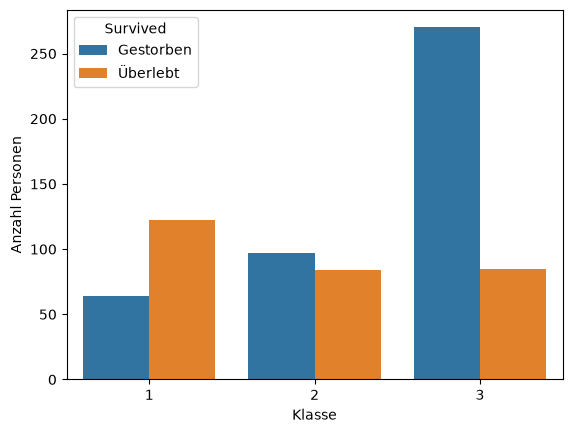

In [47]:
#Grouping Dataframe
df_copy = df.groupby(["Pclass", "Survived"], observed=False).size().reset_index(name="n")
df_copy["Survived"] = df_copy["Survived"].replace({
    0: "Gestorben",
    1: "Überlebt"
})
df_copy["Wahrscheinlichkeit"] = (
    df_copy["n"]
    / df_copy.groupby("Pclass")["n"].transform("sum")
    * 100
)

#Plotting 
sns.barplot(
    data=df_copy,
    x="Pclass",
    y="n",
    hue="Survived",
)

plt.xlabel("Klasse")
plt.ylabel("Anzahl Personen")
plt.show()

#### Überlebende nach Altersgurppe 10 Jahre

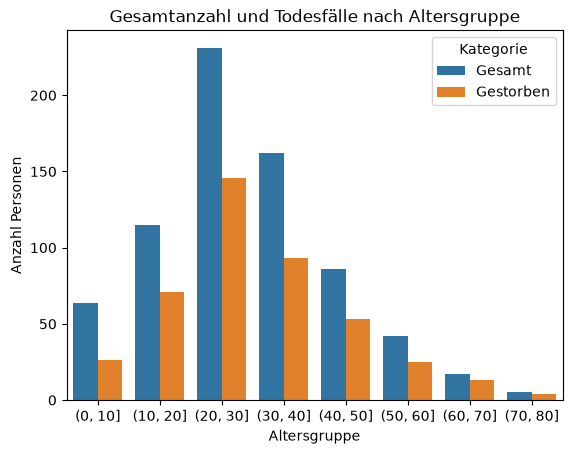

In [48]:
# Altersgruppen erstellen
df_age = df.dropna(subset=["Age"]).copy()

df_age["Age_group"] = pd.cut(
    df_age["Age"],
    bins=range(0, 90, 10)
)

# Gesamtanzahl Gäste pro Altersgruppe
total_by_age = (
    df_age.groupby("Age_group", observed=False)
    .size()
    .reset_index(name="Gesamt")
)

# Anzahl Gestorbene pro Altersgruppe
dead_by_age = (
    df_age[df_age["Survived"] == 0]
    .groupby("Age_group", observed=False)
    .size()
    .reset_index(name="Gestorben")
)

# Zusammenführen
age_stats = total_by_age.merge(
    dead_by_age,
    on="Age_group",
    how="left"
)

# Falls in einer Gruppe niemand gestorben ist
age_stats["Gestorben"] = age_stats["Gestorben"].fillna(0)

# Für Seaborn in lange Form bringen
age_plot = age_stats.melt(
    id_vars="Age_group",
    value_vars=["Gesamt", "Gestorben"],
    var_name="Kategorie",
    value_name="Anzahl"
)

age_plot["Age_group"] = age_plot["Age_group"].astype(str)

# Balkendiagramm
sns.barplot(
    data=age_plot,
    x="Age_group",
    y="Anzahl",
    hue="Kategorie"
)

plt.xlabel("Altersgruppe")
plt.ylabel("Anzahl Personen")
plt.title("Gesamtanzahl und Todesfälle nach Altersgruppe")

plt.show()

## Überlebende nach Geschlecht

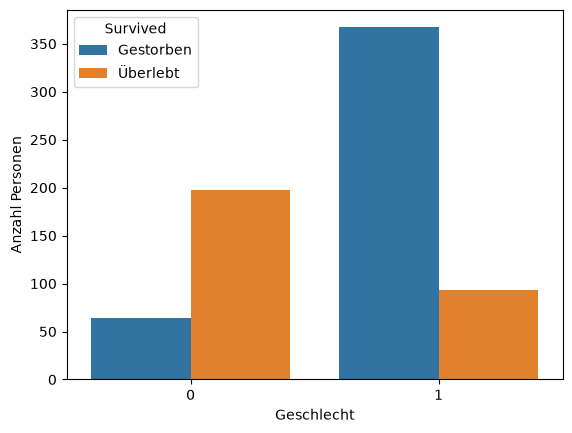

In [49]:
#Grouping Dataframe
df_copy = df.groupby(["Sex", "Survived"], observed=False).size().reset_index(name="n")
df_copy["Survived"] = df_copy["Survived"].replace({
    0: "Gestorben",
    1: "Überlebt"
})
df_copy["Wahrscheinlichkeit"] = (
    df_copy["n"]
    / df_copy.groupby("Sex")["n"].transform("sum")
    * 100
)

#Plotting 
sns.barplot(
    data=df_copy,
    x="Sex",
    y="n",
    hue="Survived",
)


plt.xlabel("Geschlecht")
plt.ylabel("Anzahl Personen")
plt.show()

## Prediction models für die Überlebenschancen 

### Random Forest

#### Train test split

In [50]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Create RF model and train

In [51]:
rf = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # Controls both the randomness of the bootstrapping and feature sampling
)

In [52]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Predict data on test set

In [53]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7972350230414746

#### Random Froest model Visualization

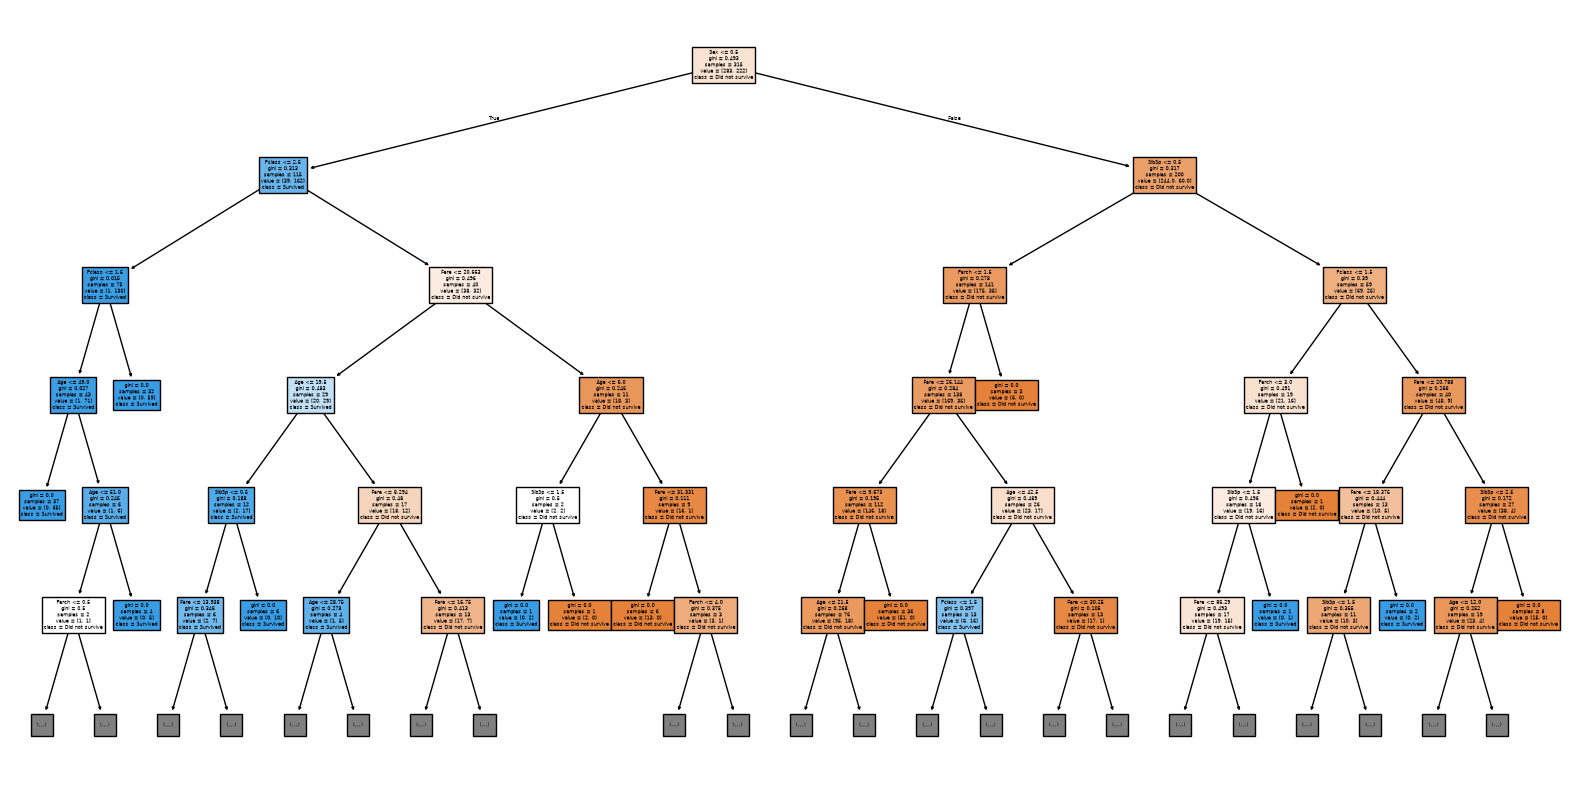

In [54]:
plt.figure(figsize=(20, 10))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['Did not survive', 'Survived'],
    filled=True,
    max_depth=5
)

plt.show()

#### Feature importance with permutation importance

![permutation_importance](image.png)

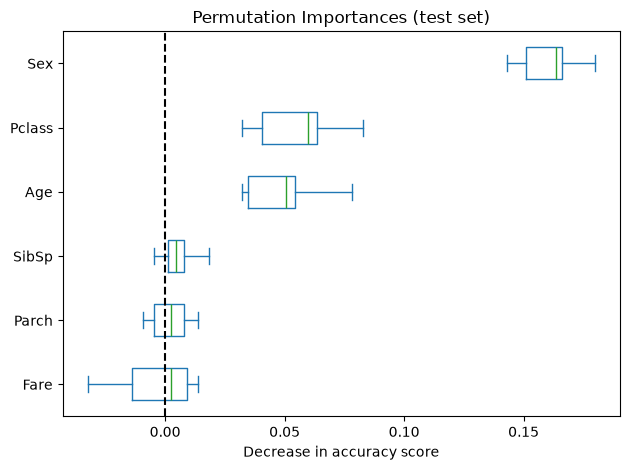

In [55]:
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

### Gradient Boosting

#### Create GB model and train

In [56]:
gb = GradientBoostingClassifier(
    learning_rate=0.05,    
    max_leaf_nodes=15,     
    min_samples_leaf=30,
    random_state=42,
)
gb.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",30
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.Values must be in the range `[2, inf)`.If `None`, then unlimited number of leaf nodes.",15
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3


#### Predict data on test set

In [57]:
y_pred = gb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8018433179723502

#### Gradient Boosting model Visualization

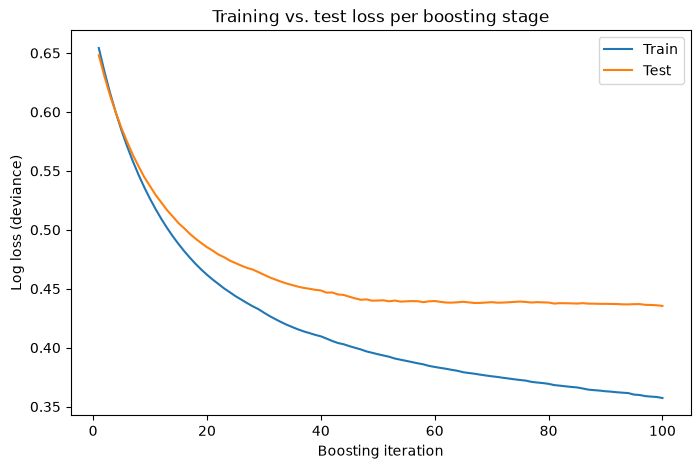

Best iteration on test loss: 100 / 100


In [58]:
train_deviance = np.array([
    log_loss(y_train, proba[:, 1]) for proba in gb.staged_predict_proba(X_train)
])
test_deviance = np.array([
    log_loss(y_test, proba[:, 1]) for proba in gb.staged_predict_proba(X_test)
])

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, gb.n_estimators + 1), train_deviance, label="Train")
plt.plot(np.arange(1, gb.n_estimators + 1), test_deviance, label="Test")
plt.xlabel("Boosting iteration")
plt.ylabel("Log loss (deviance)")
plt.title("Training vs. test loss per boosting stage")
plt.legend()
plt.show()

print(f"Best iteration on test loss: {test_deviance.argmin() + 1} / {gb.n_estimators}")

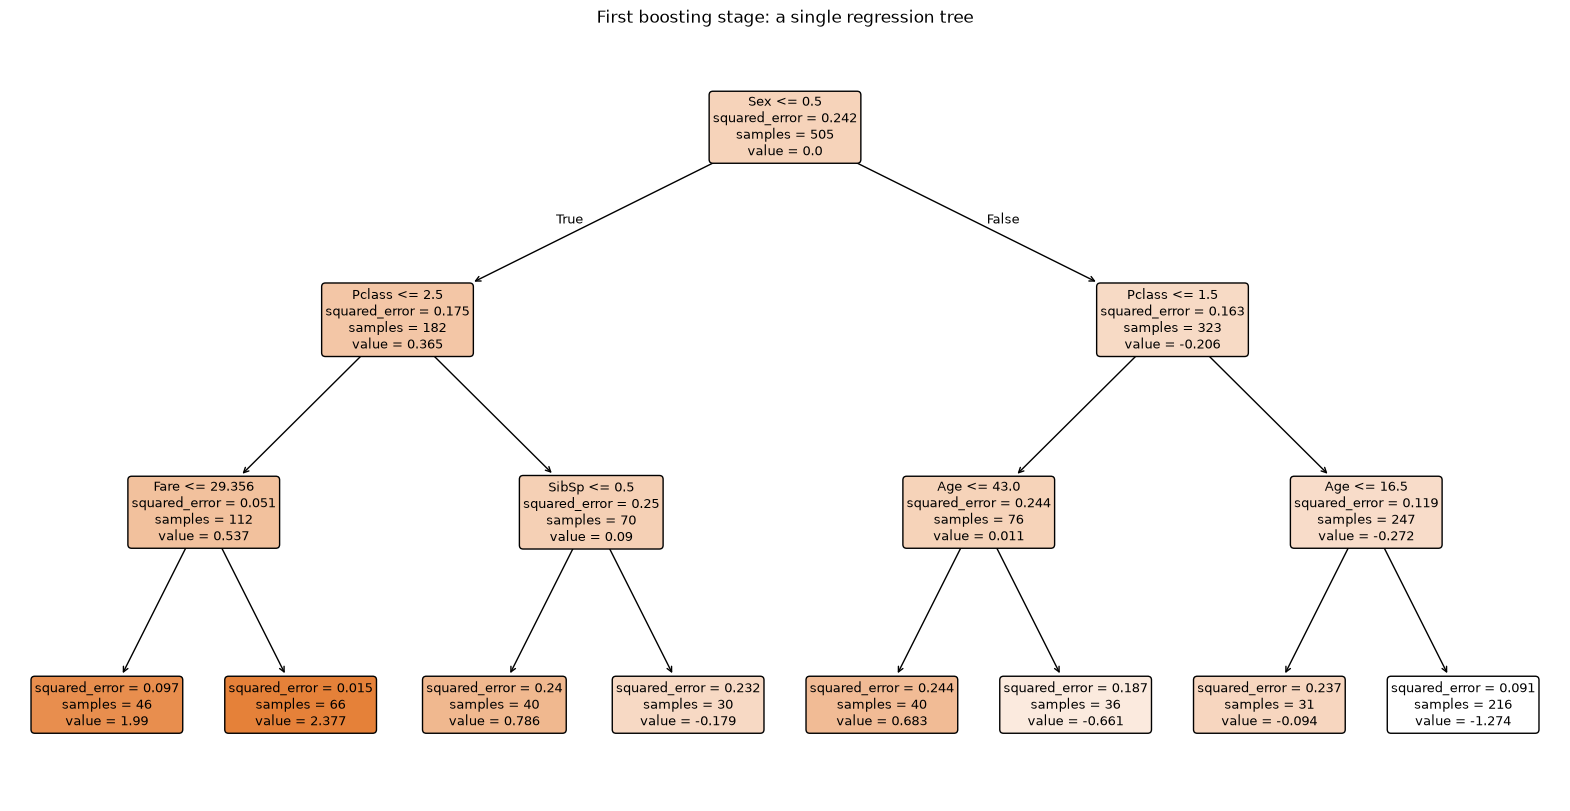

In [59]:
plt.figure(figsize=(20, 10))

plot_tree(
    gb.estimators_[0, 0],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("First boosting stage: a single regression tree")
plt.show()

#### Feature importance with permutation importance

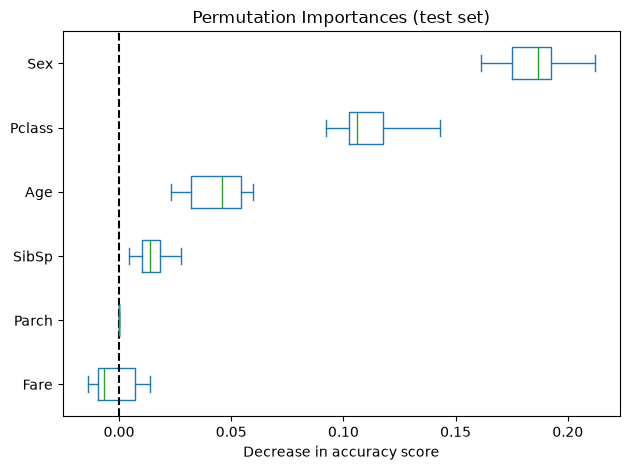

In [60]:
result = permutation_importance(
    gb, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

#### Person predictor

In [61]:
person = pd.DataFrame({
'Pclass': [1],
'Sex': [0],
'Age':[23],
'SibSp': [2],
'Parch': [3],
'Fare': [100]
})

pred_gb = gb.predict_proba(person)[0]
pred_rf = rf.predict_proba(person)[0]

In [62]:
print(f"Gradient Boosting Survived: {pred_gb[1] * 100:.2f}%")
print(f"Random Forest Survived: {pred_rf[1] * 100:.2f}%")

Gradient Boosting Survived: 89.80%
Random Forest Survived: 96.00%
